# Gemma 4 12B — 사전학습 모델 기본 성능 리포트

**모델:** `gemma4:e4b` (Gemma 4 12B, Ollama 로컬 실행)  
**작성자:** woochul  
**실험 일시:** 2026-05-08  
**데이터셋:** AI 생성 이미지 101장 / 실제 인물 사진 249장 (총 350장)  
**태스크:** AI 생성 이미지 탐지 (이진 분류 — AI vs Real)  
**실행 환경:** Ollama 로컬, 이미지 512×512 리사이즈, temperature=0.1

---

### 평가 목표치
| 지표 | 목표 | 방향 |
|---|---|---|
| Accuracy | 70% 이상 | ↑ |
| Precision | 75% 이상 | ↑ |
| Recall ★ | 75% 이상 (핵심) | ↑ |
| F1 Score | 70% 이상 | ↑ |
| FPR | 20% 이하 | ↓ |
| Avg Inference Time | 30초 이하 | ↓ |

In [1]:
import subprocess, sys

# ── matplotlib 설치 확인 (hnf 환경 기본 미포함) ──
try:
    import matplotlib
except ImportError:
    print("matplotlib 미설치 — 자동 설치 중...")
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'matplotlib'], check=True)
    print("설치 완료")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Python 버전 확인
print(f"Python {sys.version}")
assert sys.version_info >= (3, 11), f"Python 3.11+ 필요 (현재: {sys.version_info})"

plt.rcParams['font.family']      = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

COLOR_PASS   = '#2ecc71'
COLOR_FAIL   = '#e74c3c'
COLOR_GEMMA  = '#8e44ad'
COLOR_VIT    = '#3498db'
COLOR_TARGET = '#f39c12'
COLOR_AI     = '#e74c3c'
COLOR_REAL   = '#3498db'

BENCH_DIR = os.path.dirname(os.path.abspath('__file__'))

TARGET = {
    'accuracy' : 70.0,
    'precision': 75.0,
    'recall'   : 75.0,
    'f1'       : 70.0,
    'fpr'      : 20.0,
    'avg_time' : 30.0,
}

# ── 데이터 로드 ──
df_summary = pd.read_csv(os.path.join(BENCH_DIR, 'benchmark_gemma4_12b_20260508_131040.csv'))
df_raw     = pd.read_csv(os.path.join(BENCH_DIR, 'gemma4_raw_20260508_131040.csv'))

# 기존 ViT 비교 기준 (best model 기준값 하드코딩)
VIT_REF = {
    'model'    : 'ai-image-detector-deploy',
    'accuracy' : 88.25, 'precision': 75.86, 'recall': 87.13,
    'f1'       : 81.11, 'fpr'      : 11.29, 'avg_time': 0.828,
    'tp': 88, 'fp': 28, 'fn': 13, 'tn': 220,
}

m = df_summary.iloc[0]
print(f'[Summary] model={m.model}, n={m.n_total}, accuracy={m.accuracy}%')
print(f'[Raw]     rows={len(df_raw)}, columns={list(df_raw.columns)}')

Python 3.11.15 (main, Mar 11 2026, 17:14:47) [Clang 20.1.8 ]
[Summary] model=gemma4:e4b, n=350, accuracy=65.33%
[Raw]     rows=350, columns=['image_path', 'true_label', 'verdict', 'confidence', 'pred_label', 'reason', 'elapsed', 'error']


---
## 1. 핵심 지표 요약

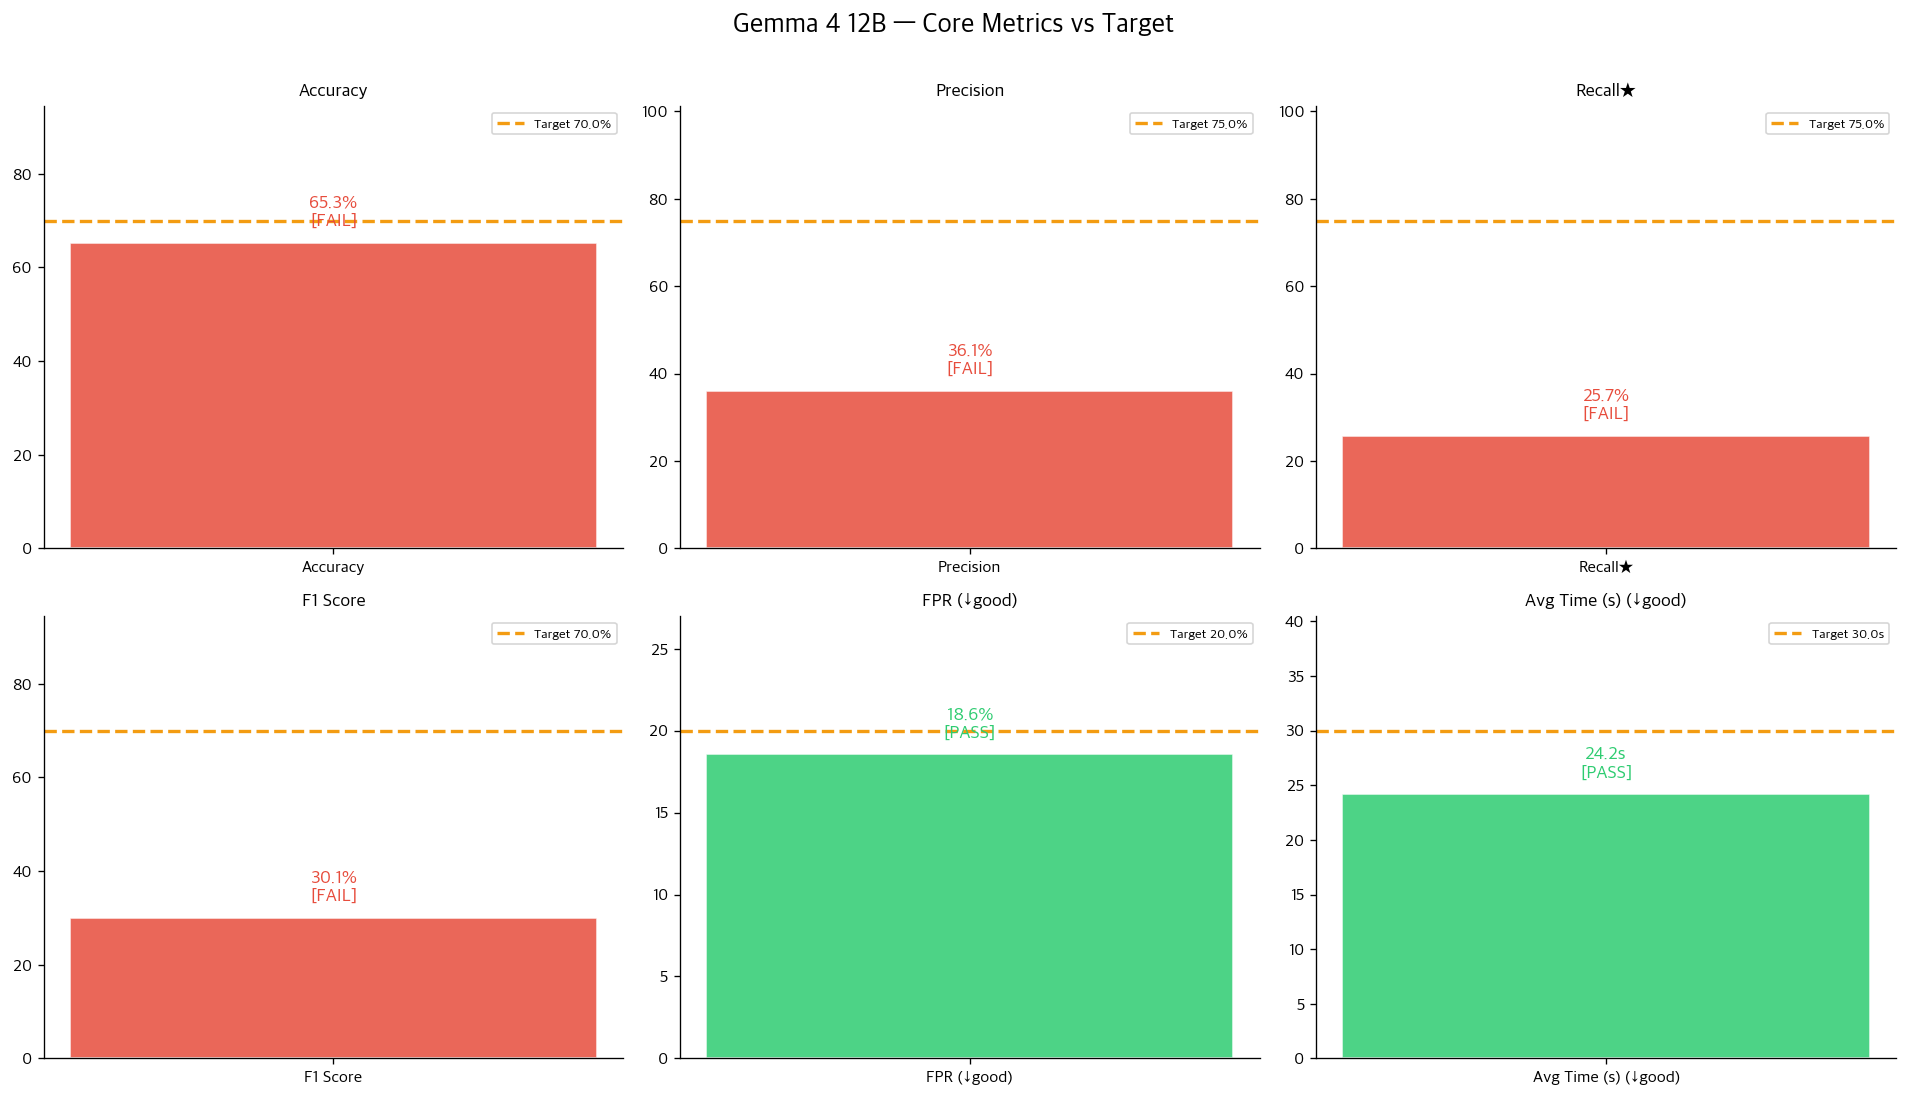

Saved: charts/gemma4_core_metrics.png


In [2]:
metrics       = ['accuracy', 'precision', 'recall', 'f1', 'fpr', 'avg_time']
metric_labels = ['Accuracy', 'Precision', 'Recall★', 'F1 Score', 'FPR (↓good)', 'Avg Time (s) (↓good)']
lower_better  = [False, False, False, False, True, True]

vals    = [float(m[metric]) for metric in metrics]
targets = [TARGET[metric]   for metric in metrics]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Gemma 4 12B — Core Metrics vs Target', fontsize=16, fontweight='bold', y=1.01)

for ax, metric, label, val, target, lower in zip(
        axes.flat, metrics, metric_labels, vals, targets, lower_better):

    ok    = (val <= target) if lower else (val >= target)
    color = COLOR_PASS if ok else COLOR_FAIL
    unit  = 's' if 'time' in metric else '%'

    bar = ax.bar([label], [val], color=color, alpha=0.85, edgecolor='white', width=0.5)
    ax.axhline(target, color=COLOR_TARGET, linestyle='--', linewidth=2,
               label=f'Target {target}{unit}')

    ax.set_ylim(0, max(val, target) * 1.35)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

    badge = 'PASS' if ok else 'FAIL'
    badge_color = COLOR_PASS if ok else COLOR_FAIL
    ax.text(0, val + max(val, target) * 0.05,
            f'{val:.1f}{unit}\n[{badge}]', ha='center', fontsize=11,
            fontweight='bold', color=badge_color)

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_core_metrics.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: charts/gemma4_core_metrics.png')

---
## 2. 목표치 달성 현황표

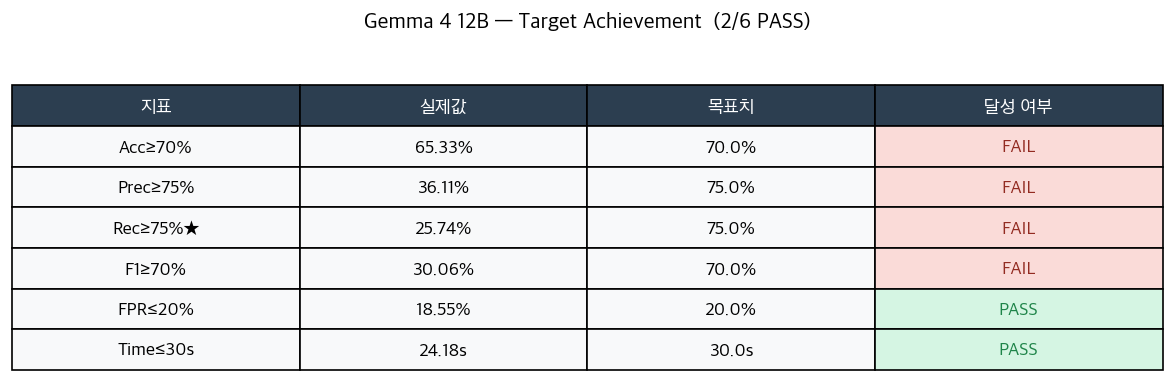

총 2/6 항목 목표 달성


In [3]:
check_cfg = [
    ('Acc≥70%',   'accuracy',  70.0,  False),
    ('Prec≥75%',  'precision', 75.0,  False),
    ('Rec≥75%★',  'recall',    75.0,  False),
    ('F1≥70%',    'f1',        70.0,  False),
    ('FPR≤20%',   'fpr',       20.0,  True),
    ('Time≤30s',  'avg_time',  30.0,  True),
]

row_data  = []
pass_cnt  = 0
for col_label, metric, tgt, lower in check_cfg:
    val = float(m[metric])
    ok  = (val <= tgt) if lower else (val >= tgt)
    pass_cnt += int(ok)
    unit = 's' if 'time' in metric else '%'
    row_data.append([col_label, f'{val:.2f}{unit}', f'{tgt}{unit}', 'PASS' if ok else 'FAIL'])

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
col_headers = ['지표', '실제값', '목표치', '달성 여부']
tbl = ax.table(cellText=row_data, colLabels=col_headers,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.3, 2.2)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 3:
        txt = cell.get_text().get_text()
        if txt == 'PASS':
            cell.set_facecolor('#d5f5e3')
            cell.set_text_props(color='#1e8449', fontweight='bold')
        elif txt == 'FAIL':
            cell.set_facecolor('#fadbd8')
            cell.set_text_props(color='#922b21', fontweight='bold')
    else:
        cell.set_facecolor('#f8f9fa')

fig.suptitle(f'Gemma 4 12B — Target Achievement  ({pass_cnt}/6 PASS)',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_target_table.png'), bbox_inches='tight', dpi=150)
plt.show()
print(f'총 {pass_cnt}/6 항목 목표 달성')

---
## 3. 혼동 행렬 (Confusion Matrix)

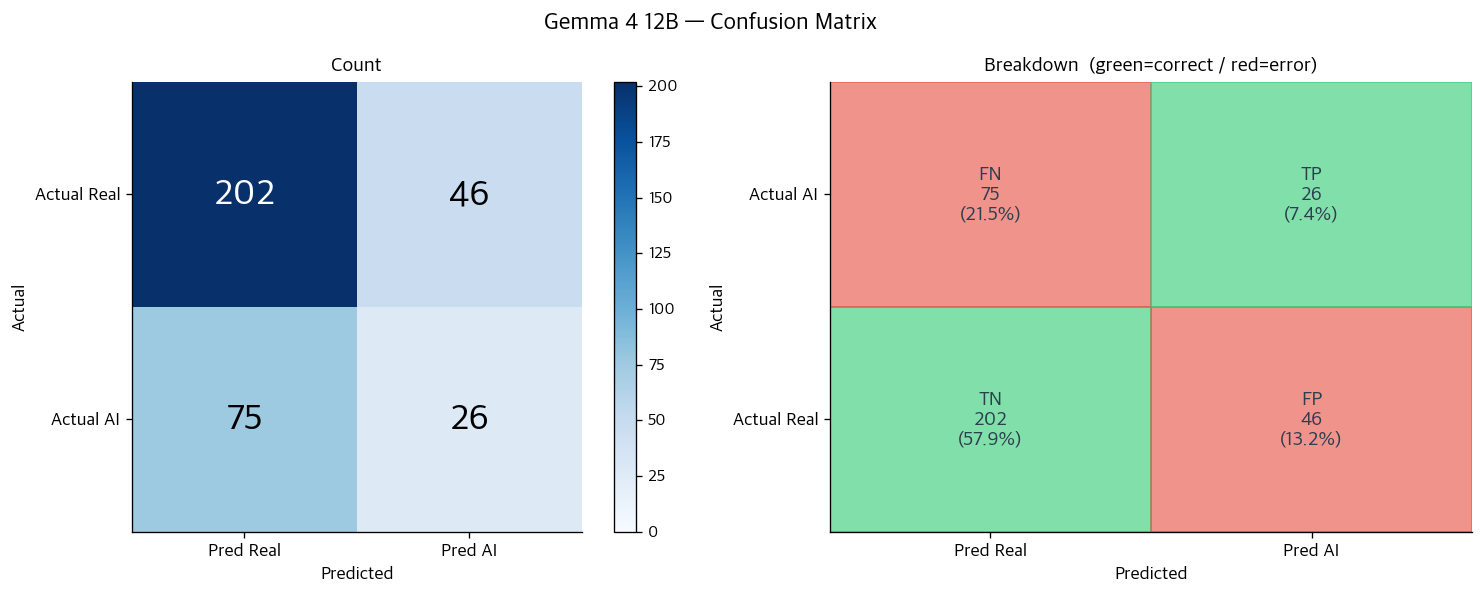

TP (AI 정탐)   : 26  (25.7% of all AI images)
FN (AI 미탐)   : 75  (74.3% of all AI images)  ← 핵심 문제
FP (Real 오탐) : 46  (18.5% of all Real images)
TN (Real 정탐) : 202  (81.5% of all Real images)


In [4]:
tp, fp, fn, tn = int(m.tp), int(m.fp), int(m.fn), int(m.tn)
cm = np.array([[tn, fp], [fn, tp]])
total = tp + fp + fn + tn

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gemma 4 12B — Confusion Matrix', fontsize=14, fontweight='bold')

# 왼쪽: 절대 수치
ax = axes[0]
im = ax.imshow(cm, cmap='Blues', vmin=0)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred Real', 'Pred AI'], fontsize=11)
ax.set_yticklabels(['Actual Real', 'Actual AI'], fontsize=11)
ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Count', fontsize=12, fontweight='bold')
for r in range(2):
    for c in range(2):
        ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                fontsize=22, fontweight='bold',
                color='white' if cm[r, c] > cm.max() * 0.5 else 'black')
plt.colorbar(im, ax=ax)

# 오른쪽: 비율
ax = axes[1]
cm_pct = cm / total * 100
labels_pct = np.array([
    [f'TN\n{tn}\n({tn/total*100:.1f}%)', f'FP\n{fp}\n({fp/total*100:.1f}%)'],
    [f'FN\n{fn}\n({fn/total*100:.1f}%)', f'TP\n{tp}\n({tp/total*100:.1f}%)']
])

colors_map = np.array([
    [COLOR_PASS, COLOR_FAIL],
    [COLOR_FAIL, COLOR_PASS]
])
for r in range(2):
    for c in range(2):
        rect = plt.Rectangle([c - 0.5, r - 0.5], 1, 1,
                              color=colors_map[r, c], alpha=0.6)
        ax.add_patch(rect)
        ax.text(c, r, labels_pct[r, c], ha='center', va='center',
                fontsize=12, fontweight='bold', color='#2c3e50')
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred Real', 'Pred AI'], fontsize=11)
ax.set_yticklabels(['Actual Real', 'Actual AI'], fontsize=11)
ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Breakdown  (green=correct / red=error)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_confusion.png'), bbox_inches='tight', dpi=150)
plt.show()

print(f'TP (AI 정탐)   : {tp}  ({tp/(tp+fn)*100:.1f}% of all AI images)')
print(f'FN (AI 미탐)   : {fn}  ({fn/(tp+fn)*100:.1f}% of all AI images)  ← 핵심 문제')
print(f'FP (Real 오탐) : {fp}  ({fp/(fp+tn)*100:.1f}% of all Real images)')
print(f'TN (Real 정탐) : {tn}  ({tn/(fp+tn)*100:.1f}% of all Real images)')

---
## 4. 클래스별 성능 분석 (AI 탐지 vs Real 판별)

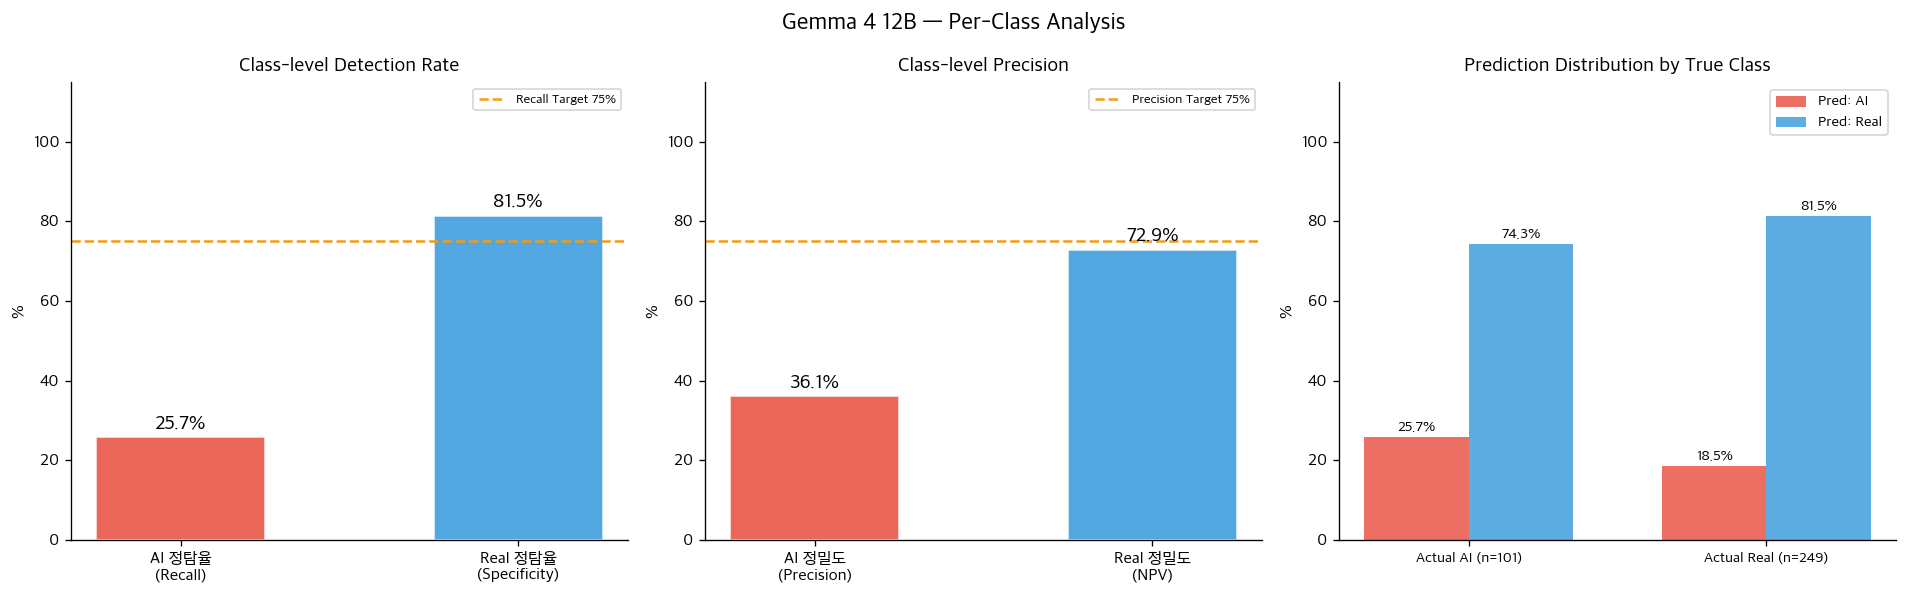


[AI 이미지 101장]
  AI로 정탐: 26장 (25.7%)
  Real로 오탐(FN): 75장 (74.3%) ← 모델이 대부분 Real로 잘못 분류

[Real 이미지 248장]
  Real로 정탐: 202장 (81.5%)
  AI로 오탐(FP): 46장 (18.5%)


In [5]:
n_ai   = tp + fn   # 실제 AI 이미지 수
n_real = fp + tn   # 실제 Real 이미지 수

ai_recall   = tp / n_ai  * 100   # = Recall
real_recall = tn / n_real * 100  # = TNR (Specificity)
ai_prec     = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
real_prec   = tn / (tn + fn) * 100 if (tn + fn) > 0 else 0

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Gemma 4 12B — Per-Class Analysis', fontsize=14, fontweight='bold')

# 1) 클래스별 정탐율
ax = axes[0]
cats   = ['AI 정탐율\n(Recall)', 'Real 정탐율\n(Specificity)']
rates  = [ai_recall, real_recall]
colors = [COLOR_AI, COLOR_REAL]
bars   = ax.bar(cats, rates, color=colors, alpha=0.85, edgecolor='white', width=0.5)
ax.axhline(75, color=COLOR_TARGET, linestyle='--', linewidth=1.5, label='Recall Target 75%')
ax.set_ylim(0, 115)
ax.set_ylabel('%')
ax.set_title('Class-level Detection Rate', fontweight='bold')
ax.legend(fontsize=8)
for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

# 2) 클래스별 정밀도
ax = axes[1]
cats2   = ['AI 정밀도\n(Precision)', 'Real 정밀도\n(NPV)']
precs   = [ai_prec, real_prec]
bars2   = ax.bar(cats2, precs, color=colors, alpha=0.85, edgecolor='white', width=0.5)
ax.axhline(75, color=COLOR_TARGET, linestyle='--', linewidth=1.5, label='Precision Target 75%')
ax.set_ylim(0, 115)
ax.set_ylabel('%')
ax.set_title('Class-level Precision', fontweight='bold')
ax.legend(fontsize=8)
for bar, val in zip(bars2, precs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

# 3) 예측 분포 (AI/Real 각각 어떻게 예측했나)
ax = axes[2]
ai_pred_ai   = tp / n_ai   * 100
ai_pred_real = fn / n_ai   * 100
re_pred_ai   = fp / n_real * 100
re_pred_real = tn / n_real * 100

x = np.arange(2)
w = 0.35
b1 = ax.bar(x - w/2, [ai_pred_ai, re_pred_ai],   w, label='Pred: AI',   color=COLOR_AI,   alpha=0.8)
b2 = ax.bar(x + w/2, [ai_pred_real, re_pred_real], w, label='Pred: Real', color=COLOR_REAL, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['Actual AI (n=101)', 'Actual Real (n=249)'], fontsize=9)
ax.set_ylim(0, 115)
ax.set_ylabel('%')
ax.set_title('Prediction Distribution by True Class', fontweight='bold')
ax.legend(fontsize=9)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.5,
            f'{h:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_per_class.png'), bbox_inches='tight', dpi=150)
plt.show()

print(f'\n[AI 이미지 {n_ai}장]')
print(f'  AI로 정탐: {tp}장 ({ai_recall:.1f}%)')
print(f'  Real로 오탐(FN): {fn}장 ({ai_pred_real:.1f}%) ← 모델이 대부분 Real로 잘못 분류')
print(f'\n[Real 이미지 {n_real}장]')
print(f'  Real로 정탐: {tn}장 ({real_recall:.1f}%)')
print(f'  AI로 오탐(FP): {fp}장 ({re_pred_ai:.1f}%)')

---
## 5. 신뢰도(Confidence) 분포 분석

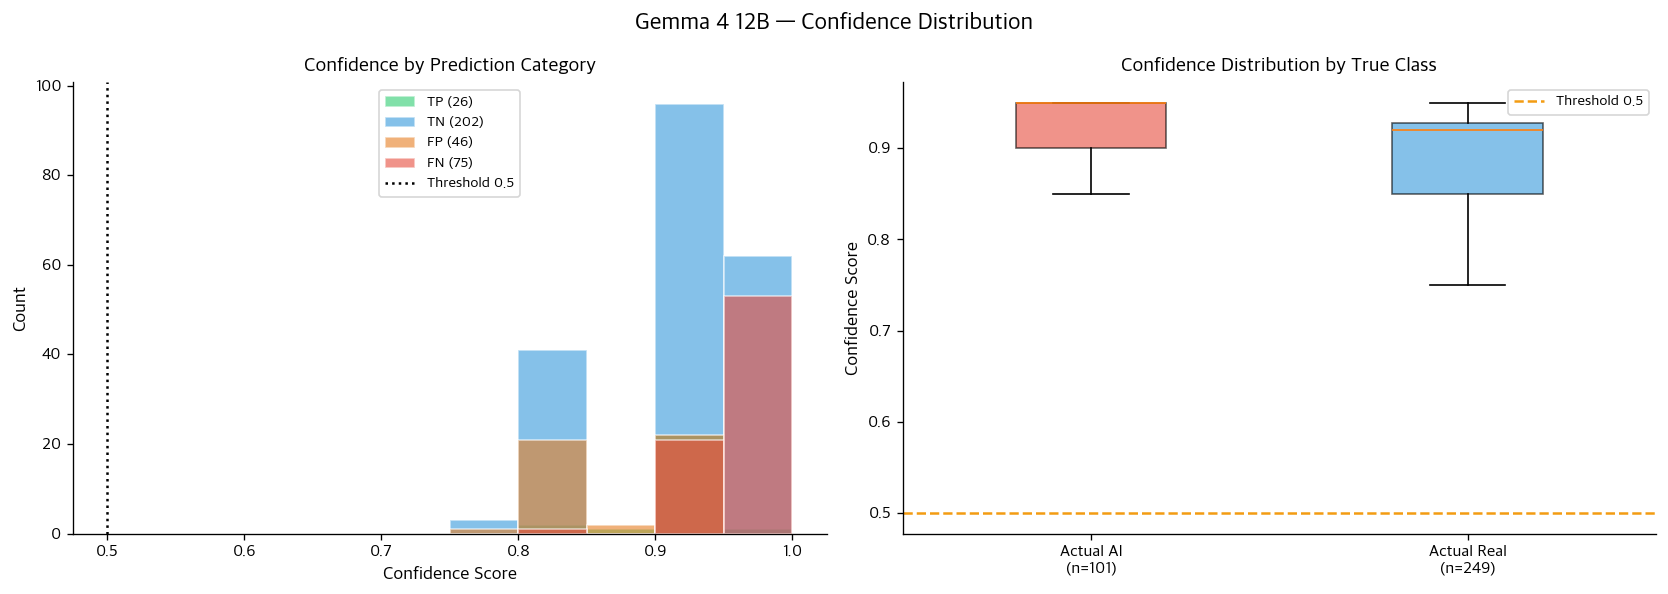

AI 이미지  평균 confidence: 0.929  (std=0.026)
Real 이미지 평균 confidence: 0.902  (std=0.044)


In [6]:
df_valid = df_raw[df_raw['verdict'].isin(['AI_GENERATED', 'REAL'])].copy()
df_valid['correct'] = (df_valid['true_label'] == df_valid['pred_label'])
df_valid['category'] = df_valid.apply(
    lambda r: ('TP' if r.pred_label==1 else 'FN') if r.true_label==1
              else ('FP' if r.pred_label==1 else 'TN'), axis=1
)

cat_colors = {'TP': '#2ecc71', 'TN': '#3498db', 'FP': '#e67e22', 'FN': '#e74c3c'}
cat_labels = {'TP': f'TP ({tp})',  'FN': f'FN ({fn})',
              'FP': f'FP ({fp})',  'TN': f'TN ({tn})'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gemma 4 12B — Confidence Distribution', fontsize=14, fontweight='bold')

# 왼쪽: 카테고리별 히스토그램
ax = axes[0]
for cat in ['TP', 'TN', 'FP', 'FN']:
    data = df_valid[df_valid['category'] == cat]['confidence']
    if len(data) > 0:
        ax.hist(data, bins=10, range=(0.5, 1.0), alpha=0.6,
                color=cat_colors[cat], label=cat_labels[cat], edgecolor='white')
ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, label='Threshold 0.5')
ax.set_xlabel('Confidence Score', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Confidence by Prediction Category', fontweight='bold')
ax.legend(fontsize=9)

# 오른쪽: Actual AI vs Actual Real 신뢰도 박스플롯
ax = axes[1]
ai_conf   = df_valid[df_valid['true_label'] == 1]['confidence']
real_conf = df_valid[df_valid['true_label'] == 0]['confidence']
bp = ax.boxplot([ai_conf, real_conf], patch_artist=True,
                labels=['Actual AI\n(n=101)', 'Actual Real\n(n=249)'],
                widths=0.4)
for patch, color in zip(bp['boxes'], [COLOR_AI, COLOR_REAL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(0.5, color=COLOR_TARGET, linestyle='--', linewidth=1.5, label='Threshold 0.5')
ax.set_ylabel('Confidence Score', fontsize=11)
ax.set_title('Confidence Distribution by True Class', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_confidence.png'), bbox_inches='tight', dpi=150)
plt.show()

print(f'AI 이미지  평균 confidence: {ai_conf.mean():.3f}  (std={ai_conf.std():.3f})')
print(f'Real 이미지 평균 confidence: {real_conf.mean():.3f}  (std={real_conf.std():.3f})')

---
## 6. 추론 시간 분석

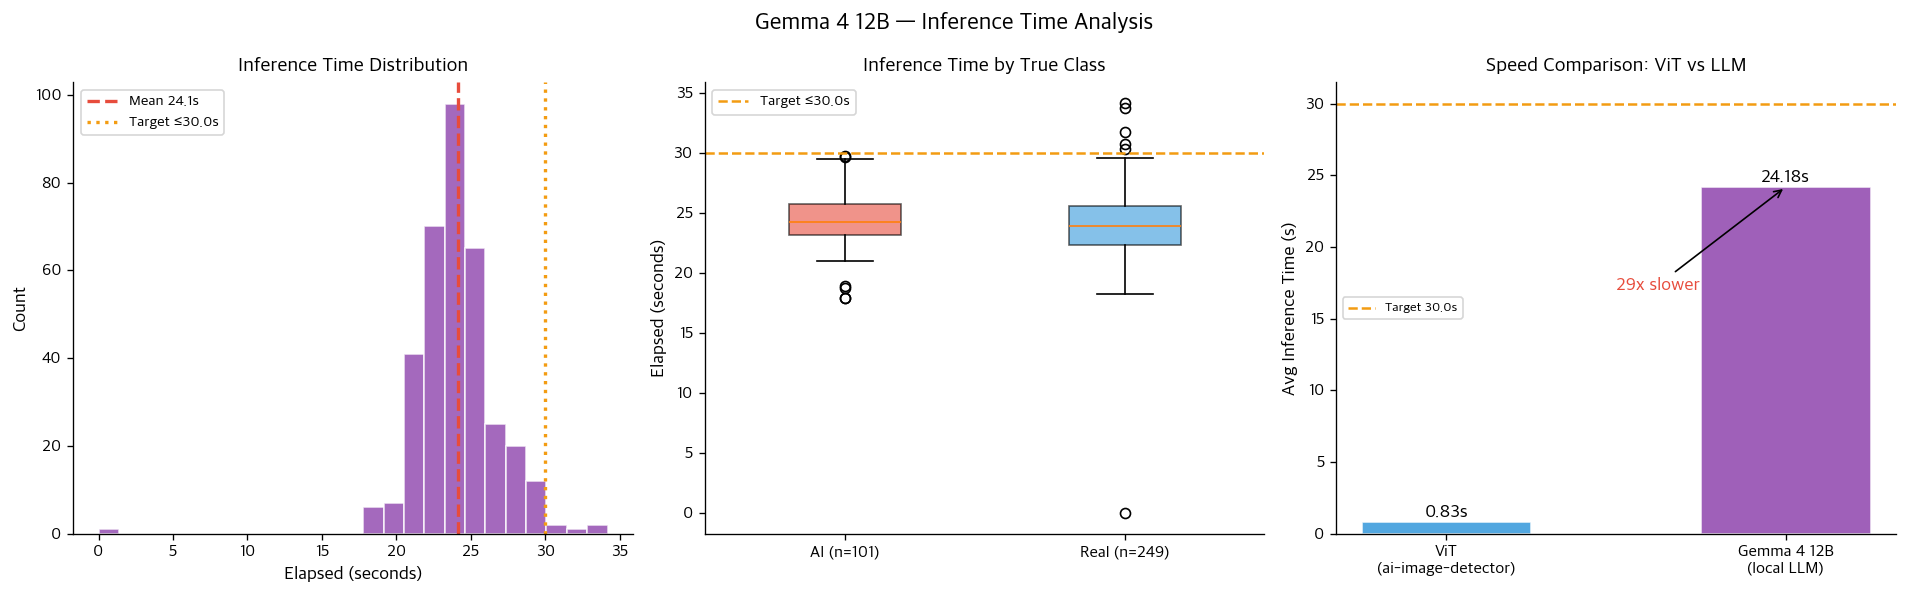

Avg time: 24.11s  (median=23.96s)
Min: 0.00s  Max: 34.17s
ViT 대비 29배 느림


In [7]:
df_valid2 = df_raw.dropna(subset=['elapsed']).copy()
df_valid2['elapsed'] = pd.to_numeric(df_valid2['elapsed'], errors='coerce')
df_valid2 = df_valid2.dropna(subset=['elapsed'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Gemma 4 12B — Inference Time Analysis', fontsize=14, fontweight='bold')

# 1) 전체 히스토그램
ax = axes[0]
ax.hist(df_valid2['elapsed'], bins=25, color=COLOR_GEMMA, alpha=0.8, edgecolor='white')
ax.axvline(df_valid2['elapsed'].mean(), color=COLOR_FAIL, linestyle='--',
           linewidth=2, label=f'Mean {df_valid2["elapsed"].mean():.1f}s')
ax.axvline(TARGET['avg_time'], color=COLOR_TARGET, linestyle=':',
           linewidth=2, label=f'Target ≤{TARGET["avg_time"]}s')
ax.set_xlabel('Elapsed (seconds)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Inference Time Distribution', fontweight='bold')
ax.legend(fontsize=9)

# 2) AI vs Real 추론 시간 비교
ax = axes[1]
ai_time   = df_valid2[df_valid2['true_label'] == 1]['elapsed']
real_time = df_valid2[df_valid2['true_label'] == 0]['elapsed']
bp = ax.boxplot([ai_time, real_time], patch_artist=True,
                labels=[f'AI (n={len(ai_time)})', f'Real (n={len(real_time)})'],
                widths=0.4)
for patch, color in zip(bp['boxes'], [COLOR_AI, COLOR_REAL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(TARGET['avg_time'], color=COLOR_TARGET, linestyle='--',
           linewidth=1.5, label=f'Target ≤{TARGET["avg_time"]}s')
ax.set_ylabel('Elapsed (seconds)', fontsize=11)
ax.set_title('Inference Time by True Class', fontweight='bold')
ax.legend(fontsize=9)

# 3) ViT vs Gemma 속도 비교
ax = axes[2]
models_cmp  = ['ViT\n(ai-image-detector)', 'Gemma 4 12B\n(local LLM)']
times_cmp   = [VIT_REF['avg_time'], float(m['avg_time'])]
colors_cmp  = [COLOR_VIT, COLOR_GEMMA]
bars_cmp    = ax.bar(models_cmp, times_cmp, color=colors_cmp, alpha=0.85,
                     edgecolor='white', width=0.5)
ax.axhline(TARGET['avg_time'], color=COLOR_TARGET, linestyle='--',
           linewidth=1.5, label=f'Target {TARGET["avg_time"]}s')
ax.set_ylabel('Avg Inference Time (s)', fontsize=11)
ax.set_title('Speed Comparison: ViT vs LLM', fontweight='bold')
ax.legend(fontsize=8)
for bar, val in zip(bars_cmp, times_cmp):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.2f}s', ha='center', fontsize=11, fontweight='bold')
ax.annotate(f'{times_cmp[1]/times_cmp[0]:.0f}x slower',
            xy=(1, times_cmp[1]), xytext=(0.5, times_cmp[1]*0.7),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=11, fontweight='bold', color=COLOR_FAIL)

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_time.png'), bbox_inches='tight', dpi=150)
plt.show()

print(f'Avg time: {df_valid2["elapsed"].mean():.2f}s  (median={df_valid2["elapsed"].median():.2f}s)')
print(f'Min: {df_valid2["elapsed"].min():.2f}s  Max: {df_valid2["elapsed"].max():.2f}s')
print(f'ViT 대비 {float(m.avg_time)/VIT_REF["avg_time"]:.0f}배 느림')

---
## 7. 오분류 패턴 분석 (FN & FP)

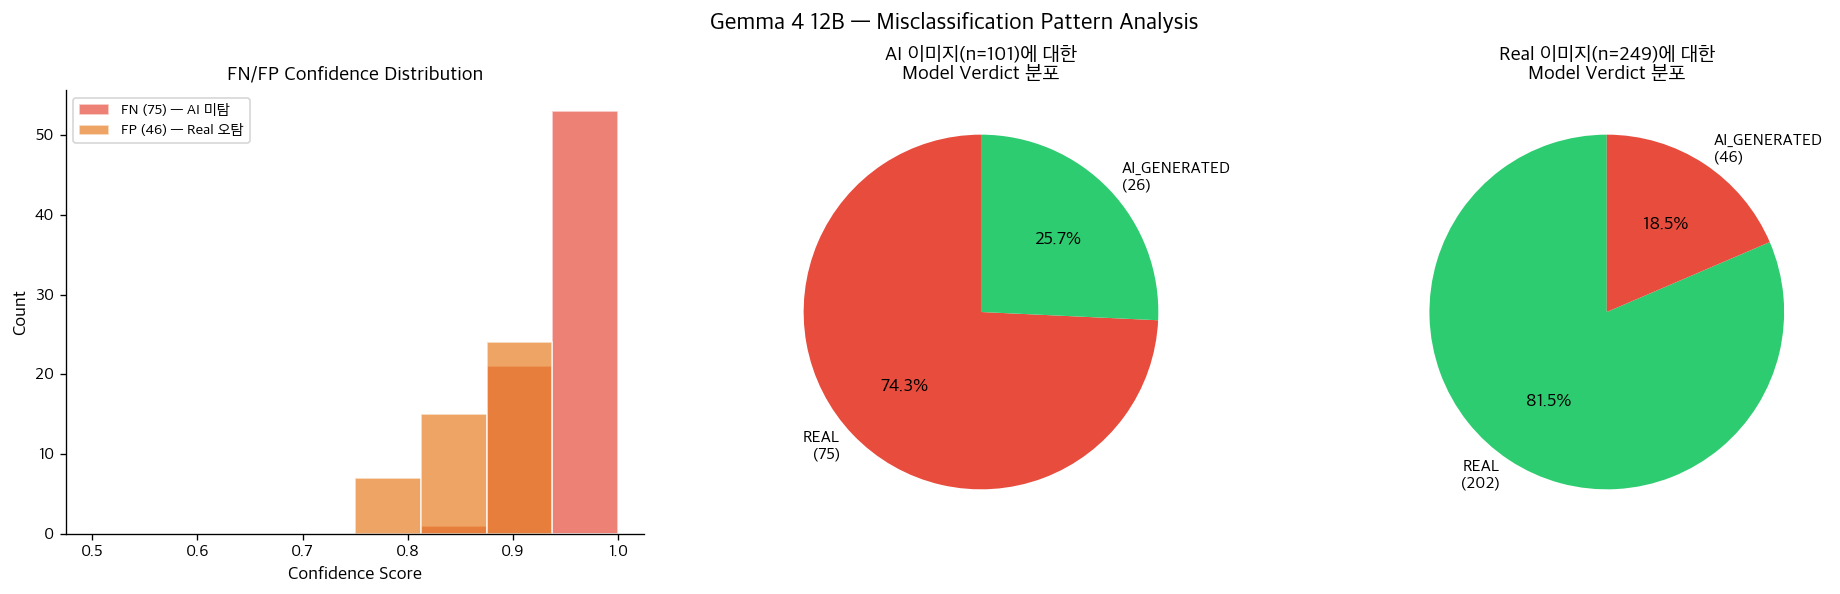


[FN 샘플 — AI 이미지인데 Real로 판단한 예시 3건]
  ai_0001.png: verdict=REAL, conf=0.92
    이유: 피부와 머리카락의 질감이 자연스럽고, 배경의 흐림 처리(bokeh)와 조명 및 그림자 방향이 일관되어 실제 촬영된 사진의 특징을 보입니다.
  ai_0002.jpg: verdict=REAL, conf=0.95
    이유: 피부, 주름, 옷의 주름 등 전반적인 텍스처와 조명, 그림자가 매우 자연스럽고 일관성이 높아 실제 촬영 사진으로 판단됩니다.
  ai_0007.png: verdict=REAL, conf=0.92
    이유: 피부, 머리카락, 옷의 주름 등 전반적인 질감과 디테일이 매우 자연스러우며, AI 생성 특유의 부자연스러운 패턴이나 해부학적 오류가 관찰되지 않습니다.


In [8]:
fn_rows = df_valid[df_valid['category'] == 'FN'].reset_index(drop=True)
fp_rows = df_valid[df_valid['category'] == 'FP'].reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Gemma 4 12B — Misclassification Pattern Analysis', fontsize=14, fontweight='bold')

# 1) FN/FP 신뢰도 분포
ax = axes[0]
if len(fn_rows) > 0:
    ax.hist(fn_rows['confidence'], bins=8, range=(0.5,1.0), alpha=0.7,
            color=COLOR_FAIL, label=f'FN ({len(fn_rows)}) — AI 미탐', edgecolor='white')
if len(fp_rows) > 0:
    ax.hist(fp_rows['confidence'], bins=8, range=(0.5,1.0), alpha=0.7,
            color='#e67e22', label=f'FP ({len(fp_rows)}) — Real 오탐', edgecolor='white')
ax.set_xlabel('Confidence Score', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('FN/FP Confidence Distribution', fontweight='bold')
ax.legend(fontsize=9)

# 2) Verdict 분포 (FN: AI 이미지인데 어떤 verdict 받았나)
ax = axes[1]
fn_verdict = df_valid[df_valid['true_label'] == 1]['verdict'].value_counts()
colors_verdict = [COLOR_PASS if v == 'AI_GENERATED' else COLOR_FAIL for v in fn_verdict.index]
wedges, texts, autotexts = ax.pie(
    fn_verdict.values,
    labels=[f'{v}\n({c})' for v, c in fn_verdict.items()],
    colors=colors_verdict,
    autopct='%1.1f%%',
    startangle=90
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax.set_title('AI 이미지(n=101)에 대한\nModel Verdict 분포', fontweight='bold')

# 3) Real 이미지 verdict 분포
ax = axes[2]
real_verdict = df_valid[df_valid['true_label'] == 0]['verdict'].value_counts()
colors_real = [COLOR_FAIL if v == 'AI_GENERATED' else COLOR_PASS for v in real_verdict.index]
wedges2, texts2, autotexts2 = ax.pie(
    real_verdict.values,
    labels=[f'{v}\n({c})' for v, c in real_verdict.items()],
    colors=colors_real,
    autopct='%1.1f%%',
    startangle=90
)
for at in autotexts2:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax.set_title('Real 이미지(n=249)에 대한\nModel Verdict 분포', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_misclassification.png'), bbox_inches='tight', dpi=150)
plt.show()

print('\n[FN 샘플 — AI 이미지인데 Real로 판단한 예시 3건]')
for _, row in fn_rows.head(3).iterrows():
    fname = os.path.basename(row['image_path'])
    print(f'  {fname}: verdict={row.verdict}, conf={row.confidence:.2f}')
    print(f'    이유: {row.reason[:100]}')

---
## 8. ViT 최우수 모델 vs Gemma 4 12B 비교

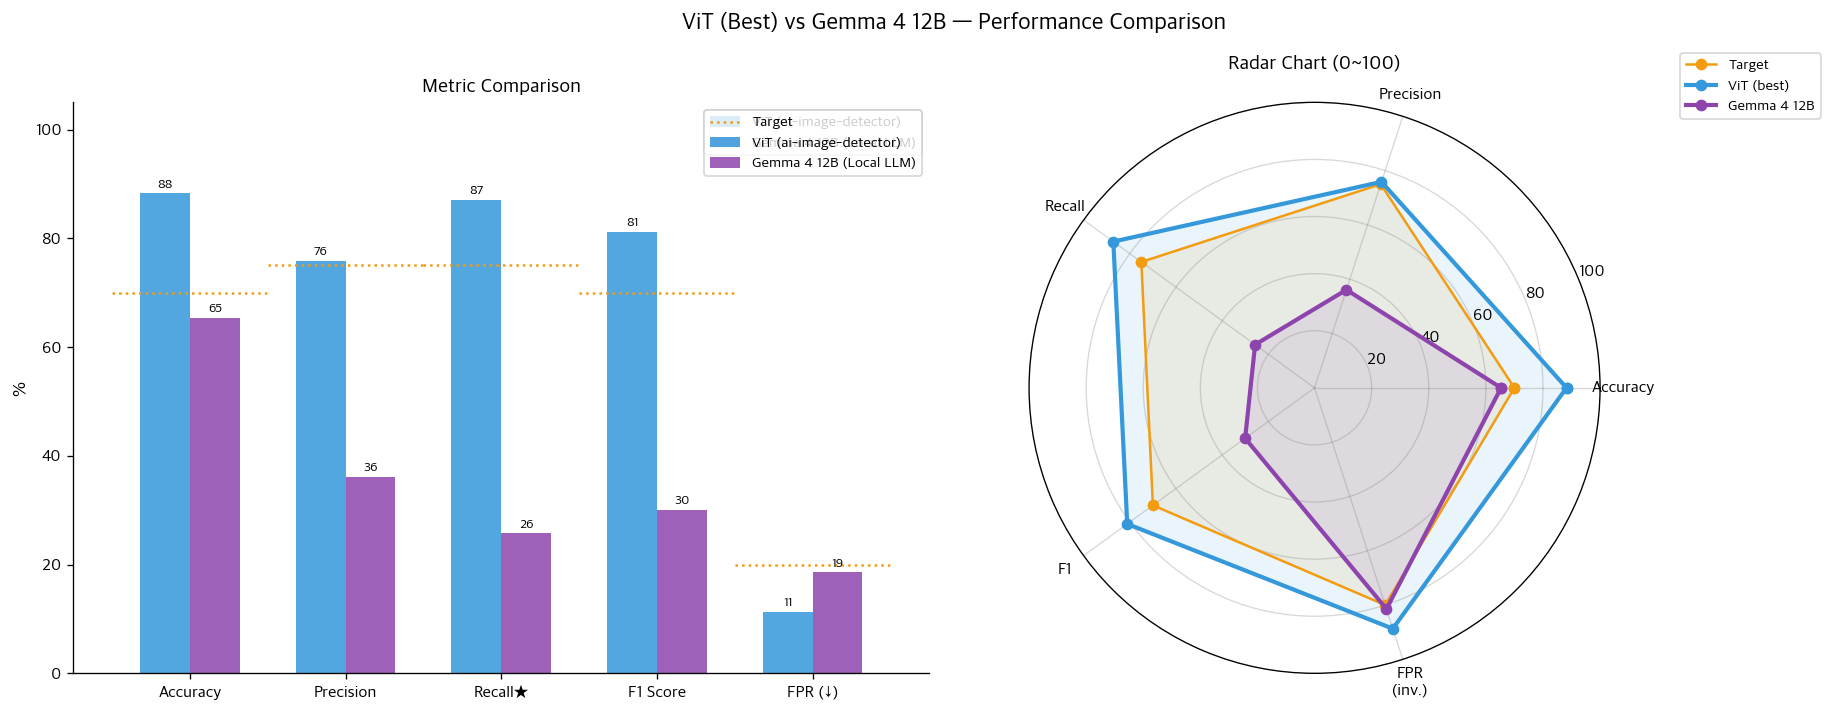


[성능 차이 요약]
  Accuracy          : ViT=88.2%  Gemma=65.3%  (-22.9% worse)
  Precision         : ViT=75.9%  Gemma=36.1%  (-39.8% worse)
  Recall★           : ViT=87.1%  Gemma=25.7%  (-61.4% worse)
  F1 Score          : ViT=81.1%  Gemma=30.1%  (-51.0% worse)
  FPR (↓)           : ViT=11.3%  Gemma=18.6%  (+7.3% worse)


In [9]:
cmp_metrics = ['accuracy', 'precision', 'recall', 'f1', 'fpr']
cmp_labels  = ['Accuracy', 'Precision', 'Recall★', 'F1 Score', 'FPR (↓)']
cmp_lower   = [False, False, False, False, True]

vit_vals   = [VIT_REF[k]   for k in cmp_metrics]
gemma_vals = [float(m[k])  for k in cmp_metrics]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ViT (Best) vs Gemma 4 12B — Performance Comparison', fontsize=14, fontweight='bold')

# 왼쪽: 지표별 막대 비교
ax = axes[0]
x = np.arange(len(cmp_metrics))
w = 0.32
b1 = ax.bar(x - w/2, vit_vals,   w, label='ViT (ai-image-detector)', color=COLOR_VIT,   alpha=0.85)
b2 = ax.bar(x + w/2, gemma_vals, w, label='Gemma 4 12B (Local LLM)', color=COLOR_GEMMA, alpha=0.85)
targets_cmp = [TARGET[k] for k in cmp_metrics]
for xi, tgt in zip(x, targets_cmp):
    ax.hlines(tgt, xi - 0.5, xi + 0.5, colors=COLOR_TARGET, linestyles=':', linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(cmp_labels, fontsize=10)
ax.set_ylim(0, 105)
ax.set_ylabel('%', fontsize=11)
ax.set_title('Metric Comparison', fontweight='bold')
ax.legend(fontsize=9)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
            f'{h:.0f}', ha='center', va='bottom', fontsize=8)
from matplotlib.lines import Line2D
ax.add_artist(ax.legend(fontsize=9))
ax.plot([], [], color=COLOR_TARGET, linestyle=':', label='Target')
ax.legend(fontsize=9)

# 오른쪽: 레이더 차트
ax = axes[1]
ax.remove()
ax = fig.add_subplot(1, 2, 2, polar=True)

radar_mets    = ['accuracy', 'precision', 'recall', 'f1', 'fpr_inv']
radar_labels2 = ['Accuracy', 'Precision', 'Recall', 'F1', 'FPR\n(inv.)']

vit_r   = [VIT_REF['accuracy'], VIT_REF['precision'], VIT_REF['recall'],
           VIT_REF['f1'], 100 - VIT_REF['fpr']]
gemma_r = [float(m['accuracy']), float(m['precision']), float(m['recall']),
           float(m['f1']), 100 - float(m['fpr'])]
target_r = [70, 75, 75, 70, 80]

angles = np.linspace(0, 2*np.pi, len(radar_mets), endpoint=False).tolist()
angles += angles[:1]
for vals_r, label_r, color_r, lw_r in [
        (target_r, 'Target',            COLOR_TARGET, 1.5),
        (vit_r,    'ViT (best)',         COLOR_VIT,    2.5),
        (gemma_r,  'Gemma 4 12B',        COLOR_GEMMA,  2.5),
    ]:
    v = vals_r + vals_r[:1]
    ax.plot(angles, v, 'o-', linewidth=lw_r, color=color_r, label=label_r)
    ax.fill(angles, v, alpha=0.1, color=color_r)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels2, fontsize=10)
ax.set_ylim(0, 100)
ax.set_title('Radar Chart (0~100)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)
ax.grid(color='grey', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_vs_vit.png'), bbox_inches='tight', dpi=150)
plt.show()

print('\n[성능 차이 요약]')
for met, lbl, lower in zip(cmp_metrics, cmp_labels, cmp_lower):
    vit_v   = VIT_REF[met]
    gemma_v = float(m[met])
    diff    = gemma_v - vit_v
    sign    = 'better' if (diff > 0) == (not lower) else 'worse'
    print(f'  {lbl:<18}: ViT={vit_v:.1f}%  Gemma={gemma_v:.1f}%  ({diff:+.1f}% {sign})')

---
## 9. 종합 점수 비교 (Spider Summary)

지표                  Gemma 4 12B     Target   ViT Best     달성
Accuracy                 65.3%     70.0%     88.2%  FAIL
Precision                36.1%     75.0%     75.9%  FAIL
Recall★                  25.7%     75.0%     87.1%  FAIL
F1 Score                 30.1%     70.0%     81.1%  FAIL
FPR                      18.6%     20.0%     11.3%  PASS
Avg Time                 24.2s     30.0s      0.8s  PASS
        Total PASS          2/6                6/6


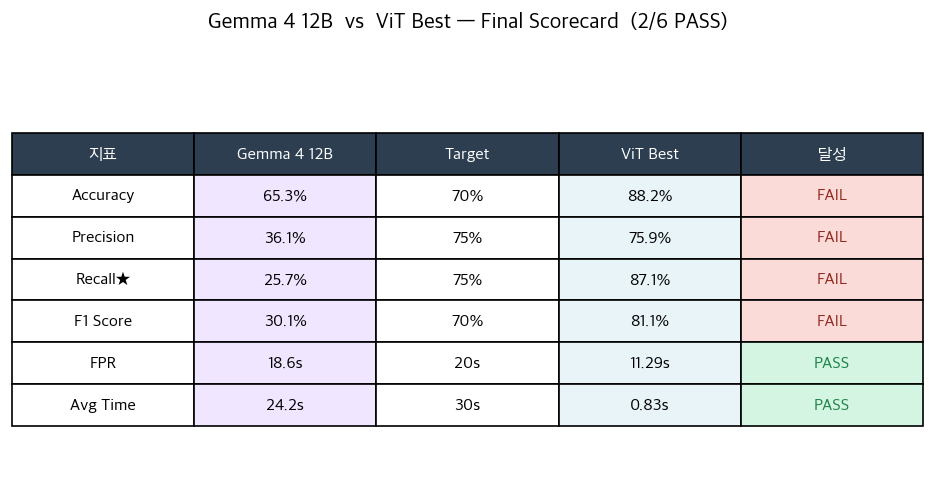

In [10]:
score_data = [
    ('Accuracy',   float(m.accuracy),    70.0,  88.25, False),
    ('Precision',  float(m.precision),   75.0,  75.86, False),
    ('Recall★',    float(m.recall),      75.0,  87.13, False),
    ('F1 Score',   float(m.f1),          70.0,  81.11, False),
    ('FPR (inv.)', 100-float(m.fpr),     80.0,  88.71, False),
    ('Speed (inv.)',max(0,100-float(m.avg_time)/30*100), 100.0*(1-1.0), max(0,100-VIT_REF['avg_time']/30*100), False),
]

print('=' * 65)
print(f'{"지표":<18} {"Gemma 4 12B":>12} {"Target":>10} {"ViT Best":>10} {"달성":>6}')
print('=' * 65)

gemma_pass = 0
check_list = [
    ('Accuracy',  float(m.accuracy),  70.0,  VIT_REF['accuracy'],  False),
    ('Precision', float(m.precision), 75.0,  VIT_REF['precision'], False),
    ('Recall★',   float(m.recall),    75.0,  VIT_REF['recall'],    False),
    ('F1 Score',  float(m.f1),        70.0,  VIT_REF['f1'],        False),
    ('FPR',       float(m.fpr),       20.0,  VIT_REF['fpr'],       True),
    ('Avg Time',  float(m.avg_time),  30.0,  VIT_REF['avg_time'],  True),
]
for label, gval, tgt, vval, lower in check_list:
    ok  = (gval <= tgt) if lower else (gval >= tgt)
    unit = 's' if label == 'Avg Time' else '%'
    gemma_pass += int(ok)
    badge = 'PASS' if ok else 'FAIL'
    print(f'{label:<18} {gval:>10.1f}{unit} {tgt:>8}{unit} {vval:>8.1f}{unit}  {badge}')
print('=' * 65)
print(f'{"Total PASS":>18} {gemma_pass:>10}/6         {"6/6":>10}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
tdata = [[r[0], f'{r[1]:.1f}%' if r[4]==False else f'{r[1]:.1f}s',
          f'{r[2]:.0f}%' if r[4]==False else f'{r[2]:.0f}s',
          f'{r[3]:.1f}%' if r[4]==False else f'{r[3]:.2f}s',
          'PASS' if ((r[1] <= r[2]) if r[4] else (r[1] >= r[2])) else 'FAIL']
         for r in check_list]
tbl2 = ax.table(cellText=tdata,
                colLabels=['지표', 'Gemma 4 12B', 'Target', 'ViT Best', '달성'],
                cellLoc='center', loc='center')
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(10)
tbl2.scale(1.3, 1.9)
for (ri, ci), cell in tbl2.get_celld().items():
    if ri == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif ci == 1:
        cell.set_facecolor('#f0e6ff')
    elif ci == 3:
        cell.set_facecolor('#e8f4f8')
    elif ci == 4 and ri > 0:
        t = cell.get_text().get_text()
        cell.set_facecolor('#d5f5e3' if t == 'PASS' else '#fadbd8')
        cell.set_text_props(color='#1e8449' if t == 'PASS' else '#922b21', fontweight='bold')
fig.suptitle(f'Gemma 4 12B  vs  ViT Best — Final Scorecard  ({gemma_pass}/6 PASS)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_scorecard.png'), bbox_inches='tight', dpi=150)
plt.show()

---
## 10. 결론 및 분석

### 핵심 결과 요약

| 항목 | 결과 |
|---|---|
| **목표 달성** | **2/6** (FPR ≤20%, Avg Time ≤30s 만 통과) |
| **가장 심각한 문제** | Recall 25.74% — AI 이미지 101장 중 **75장(74.3%)을 Real로 오판** |
| **ViT 최우수 모델 대비** | Recall 61.4%p 열세, F1 51%p 열세, 속도 약 29배 느림 |

---

### 원인 분석

**1. 판단 편향 (REAL 쪽으로 치우침)**  
모델이 이미지를 분석할 때 `REAL`로 판단하는 경향이 매우 강함.  
AI 이미지 101장 중 75장을 "자연스럽고 일관성 있다"는 근거로 Real로 오분류.

**2. 텍스트 기반 추론의 한계**  
Gemma 4는 LLM이므로 이미지를 텍스트 설명으로 변환 후 판단.  
Diffusion 모델의 주파수 도메인 아티팩트, GAN 핑거프린트 등 전역 패턴을  
텍스트 묘사만으로는 포착하기 어려움.

**3. 프롬프트 설계의 한계**  
현재 프롬프트는 시각적 판단 기준(피부 질감, 조명 등)을 텍스트로 제공.  
최신 Flux/SDXL 모델은 이런 표면적 특성을 거의 완벽하게 재현하여 탐지 회피.

---

### 개선 방향

| 우선순위 | 방향 | 기대 효과 |
|---|---|---|
| **높음** | 프롬프트 최적화 — 더 구체적인 AI 판단 기준 제공 | Recall +10~20%p 가능 |
| **높음** | Temperature 조정 (0.1 → 0.0) | 응답 일관성 향상 |
| **중간** | 임계값(Threshold) 0.5 → 0.35로 낮추기 | Recall 상승 (FPR 증가 감수) |
| **낮음** | Gemma 4 27B 등 더 큰 모델 시도 | 성능 향상 기대되나 속도 문제 |
| **참고** | **ViT 전문 모델 (ai-image-detector-deploy) 사용 권장** | 현 시점 최선 |

---

### 결론

> **Gemma 4 12B (사전학습 그대로)는 현재 AI 이미지 탐지 태스크에 적합하지 않습니다.**  
> Recall 25.74% — AI 이미지 4장 중 3장을 놓치는 수준으로, 서비스 적용 불가.  
> ViT 전문 분류 모델 대비 성능과 속도 모두 크게 열세.
>  
> 단, **FPR 18.55%** 로 Real 이미지 오탐율은 목표치를 통과했고,  
> **추론 시간 24.2초** 도 LLM 기준으로는 목표(30초) 이내.  
> 향후 fine-tuning 또는 프롬프트 엔지니어링으로 탐지 편향을 교정한다면  
> Recall 개선 여지가 있으며, 설명 가능성(근거 텍스트 생성) 측면에서 부가 활용 가치가 있음.

---
*woochul — InSIGHT Project Gemma 4 12B Baseline Report (2026-05-08)*